In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

# 6 Conv Block Module with experiments

### Import Library
- torch
- datasets, transforms
- dataloader

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## Load data for train, test and val split

Tran dataset will be using some augmentations.

In [4]:
train_transforms = transforms.Compose([
     transforms.Resize((112, 112)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
])

transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])

train_data_set = datasets.ImageFolder("../datasets/final_dataset/train", transform=train_transforms)
val_data_set = datasets.ImageFolder("../datasets/final_dataset/val", transform=transform)

train = DataLoader(
    train_data_set, 
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
    shuffle=True
    )

val = DataLoader(
    val_data_set,
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
)

## Train the model

### Load modules and architecture
* Trainer,
* Architecture

In [5]:
from modules.helper.trainer import  Trainer
from modules.architectures.Architecture import Architecture
from modules.helper.charts import gen_line_charts

### Function to define architure's actual shape

In [6]:
def add_conv_layers(model, layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = 112
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool==0:
            model.add(nn.MaxPool2d(2,2))
            size = size//2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

In [7]:
def find_best_models(df):
    best = df[df["val_accuracy"] == df["val_accuracy"].max()] # combines and remove duplicates
    return best

### Load and Construct a architecture

In [8]:
torch.manual_seed(41)

model = Architecture()

In [9]:
params, channels, size = add_conv_layers(model, 6, 1)

print(f"Total Convolutional Parameters: {params}")
print(f"Final Convolutional Out Channels: {channels}")
print(f"Final Convolutional Size: {size}")

Total Convolutional Parameters: 394560
Final Convolutional Out Channels: 256
Final Convolutional Size: 14


In [10]:
flatten_size = channels * size * size

l1_param = flatten_size * channels + channels

l2_param = channels * 36 + 36

total_params = params + l1_param + l2_param

model.add(
    nn.Flatten(),
    nn.Linear(flatten_size, channels),
    nn.ReLU(),
    nn.Linear(channels, 36)
)

print(f"TOTAL TRAINABLE PARAMETERS = {total_params}")

TOTAL TRAINABLE PARAMETERS = 13249124


In [11]:
path = "../documentations/experiments/tika-6cnn-extreme-aug"

# Using Trainer to train the model
trainer = Trainer(
    model,
    train,
    val,
    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=2e-3,
        momentum=0.9,
        weight_decay=3e-5,
    ),
    device="cuda",
    criterion = nn.CrossEntropyLoss()
)

# this is metrucs
metrics = trainer.fit(30, path, 1);

EPOCH 5 completed | Training Loss = 0.045605970544082816 | Validation Loss = 0.019103173113749296
EPOCH 10 completed | Training Loss = 0.012421328648889807 | Validation Loss = 0.004500649047548385
EPOCH 15 completed | Training Loss = 0.0075315367862437786 | Validation Loss = 0.008783672434509669
EPOCH 20 completed | Training Loss = 0.005851823773869577 | Validation Loss = 0.0027723690561308792
EPOCH 25 completed | Training Loss = 0.004872270223675095 | Validation Loss = 0.002748436707401476
EPOCH 30 completed | Training Loss = 0.0033872505912972612 | Validation Loss = 0.0020655230659114396


## Model with highest Accuracy

In [12]:
find_best_models(metrics)

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
26,27,0.002996,0.000766,0.999031,0.999032,0.999031,0.999031,0.999722,0.999724,0.999722,0.999722


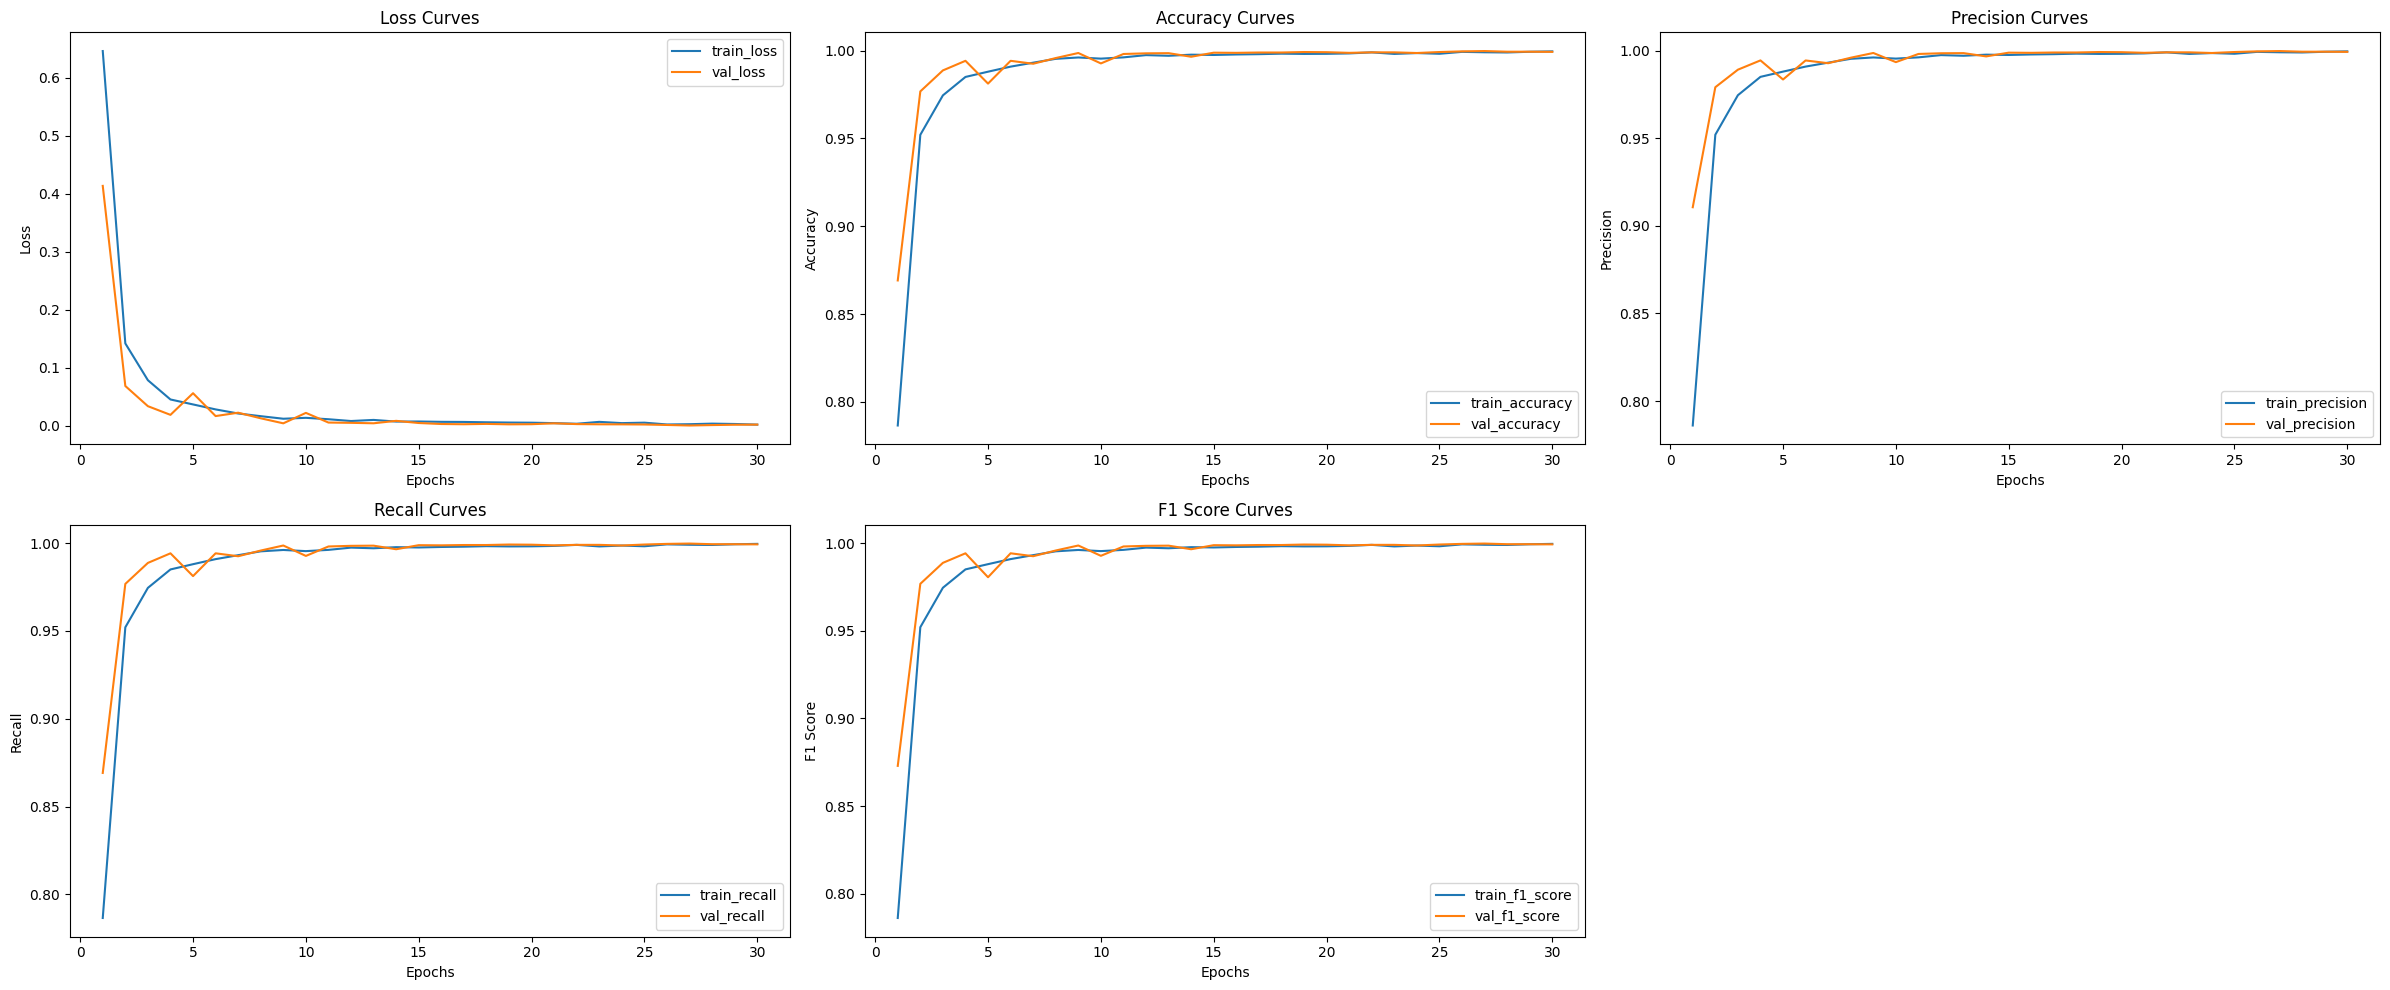

In [13]:
gen_line_charts(metrics, path, "training_metrics_graph.png", ["train_", "val_"])